This code calculates descriptive statistics for blinks and plots distributions of blink durations and interblink intervals & blinking rates.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

base_path = ""
all_durations = [] # to collect all durations
session_durations = {} # to collect duration per session
blink_rates_data = [] # to collect blink rates
all_interblink_intervals = [] # to collect all interblink intervals
session_interblink_intervals = {} # to collect intervals per session

# loading files
for folder in os.listdir(base_path):
    participant_path = os.path.join(base_path, folder)
    if not os.path.isdir(participant_path):
        continue
    blinks_path = os.path.join(participant_path, 'blinks.csv')
    if not os.path.exists(blinks_path):
        continue
    try:
        df = pd.read_csv(blinks_path)
    except Exception as e:
        print('Failed to read', blinks_path, e)
        continue
    
    if 'duration [ms]' in df.columns and len(df) > 0:
        vals = pd.to_numeric(df['duration [ms]'], errors='coerce').dropna().tolist()
        all_durations.extend(vals)
        session_durations[folder] = vals
        
        # Calculate blink rate and recording duration
        rec_period = df['end timestamp [ns]'].iloc[-1] - df['start timestamp [ns]'].iloc[0]
        rec_minutes = rec_period / 1e9 / 60 # bc originally ts are in nanoseconds
        blink_rate = len(df) / rec_minutes
        blink_rates_data.append({'Recording': folder, 'Rate': blink_rate, 'N_Blinks': len(df)})
        
        # Calculate interblink intervals (time between consecutive blinks)
        start_times = pd.to_numeric(df['start timestamp [ns]'], errors='coerce').dropna().sort_values()
        if len(start_times) > 1:
            intervals_ns = np.diff(start_times)
            intervals_sec = intervals_ns / 1e9  # convert to seconds
            intervals_ms = intervals_sec * 1000  # convert to milliseconds
            all_interblink_intervals.extend(intervals_ms)
            session_interblink_intervals[folder] = intervals_ms.tolist()

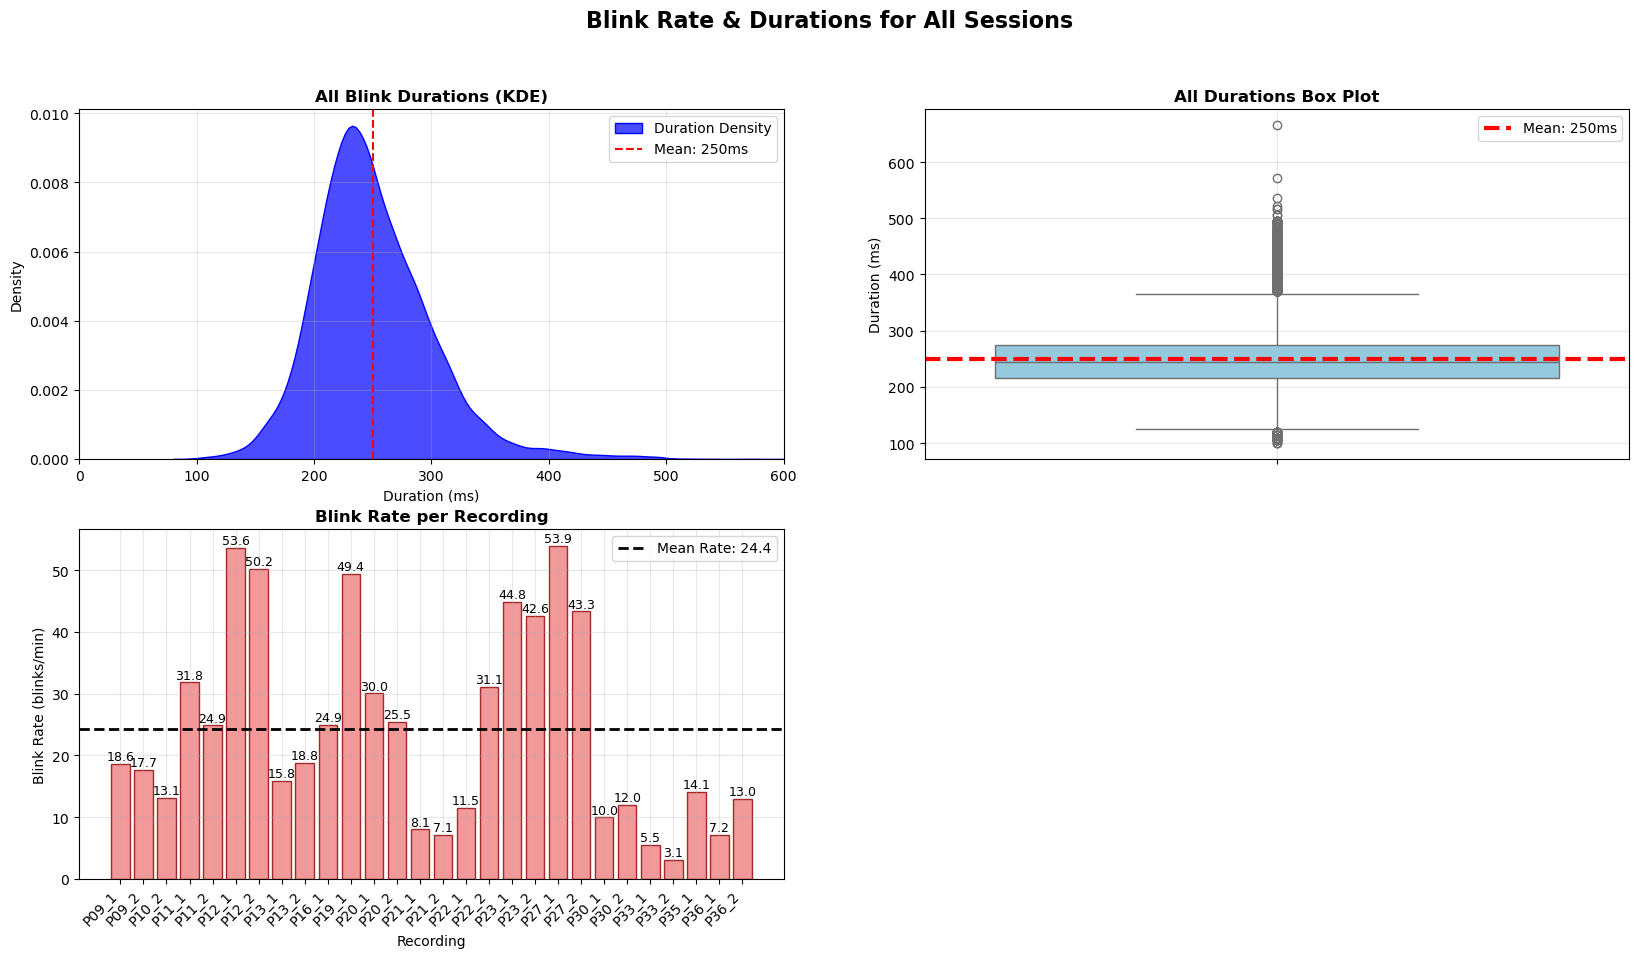

In [ ]:
# OVERALL BLINK DURATIONS & BLINK RATES

fig2, axes2 = plt.subplots(2, 2, figsize=(20, 10))
# Flattening makes it easier to reference by index (0 to 3)
ax_flat = axes2.flatten()

# durations KDE
overall_mean = np.mean(all_durations)
sns.kdeplot(all_durations, ax=ax_flat[0], color='blue', fill=True, alpha=0.7, label='Duration Density')
ax_flat[0].axvline(overall_mean, color='red', linestyle='--', label=f'Mean: {overall_mean:.0f}ms')
ax_flat[0].set_title('All Blink Durations (KDE)', fontweight='bold')
ax_flat[0].set_xlabel('Duration (ms)')
ax_flat[0].set_ylabel('Density')
ax_flat[0].set_xlim(0, 600)
ax_flat[0].grid(True, alpha=0.3)
ax_flat[0].legend()

# durations box plot
sns.boxplot(y=all_durations, ax=ax_flat[1], color='skyblue')
ax_flat[1].axhline(overall_mean, color='red', linestyle='--', linewidth=3, 
                   label=f'Mean: {overall_mean:.0f}ms')
ax_flat[1].set_title('All Durations Box Plot', fontweight='bold')
ax_flat[1].set_ylabel('Duration (ms)')
ax_flat[1].grid(True, alpha=0.3)
ax_flat[1].legend()

# blink rates plot
blink_df = pd.DataFrame(blink_rates_data)
subjects = sorted(blink_df['Recording'].unique())
rates = [blink_df[blink_df['Recording'] == sub]['Rate'].iloc[0] for sub in subjects]
mean_rate = np.mean(rates)

bars = ax_flat[2].bar(range(len(subjects)), rates, color='lightcoral', 
                      edgecolor='darkred', alpha=0.8)
ax_flat[2].axhline(mean_rate, color='black', linestyle='--', linewidth=2, 
                   label=f'Mean Rate: {mean_rate:.1f}')
ax_flat[2].set_title('Blink Rate per Recording', fontweight='bold')
ax_flat[2].set_xlabel('Recording')
ax_flat[2].set_ylabel('Blink Rate (blinks/min)')
ax_flat[2].set_xticks(range(len(subjects)))
ax_flat[2].set_xticklabels([s[:8] for s in subjects], rotation=45, ha='right')
ax_flat[2].legend()
ax_flat[2].grid(True, alpha=0.3)

# blink rate values on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax_flat[2].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{rates[i]:.1f}', ha='center', va='bottom', fontsize=9)

ax_flat[3].axis('off') # to show 3 plots instead of 4

plt.suptitle('Blink Rate & Durations for All Sessions', fontsize=16, fontweight='bold')
plt.show()

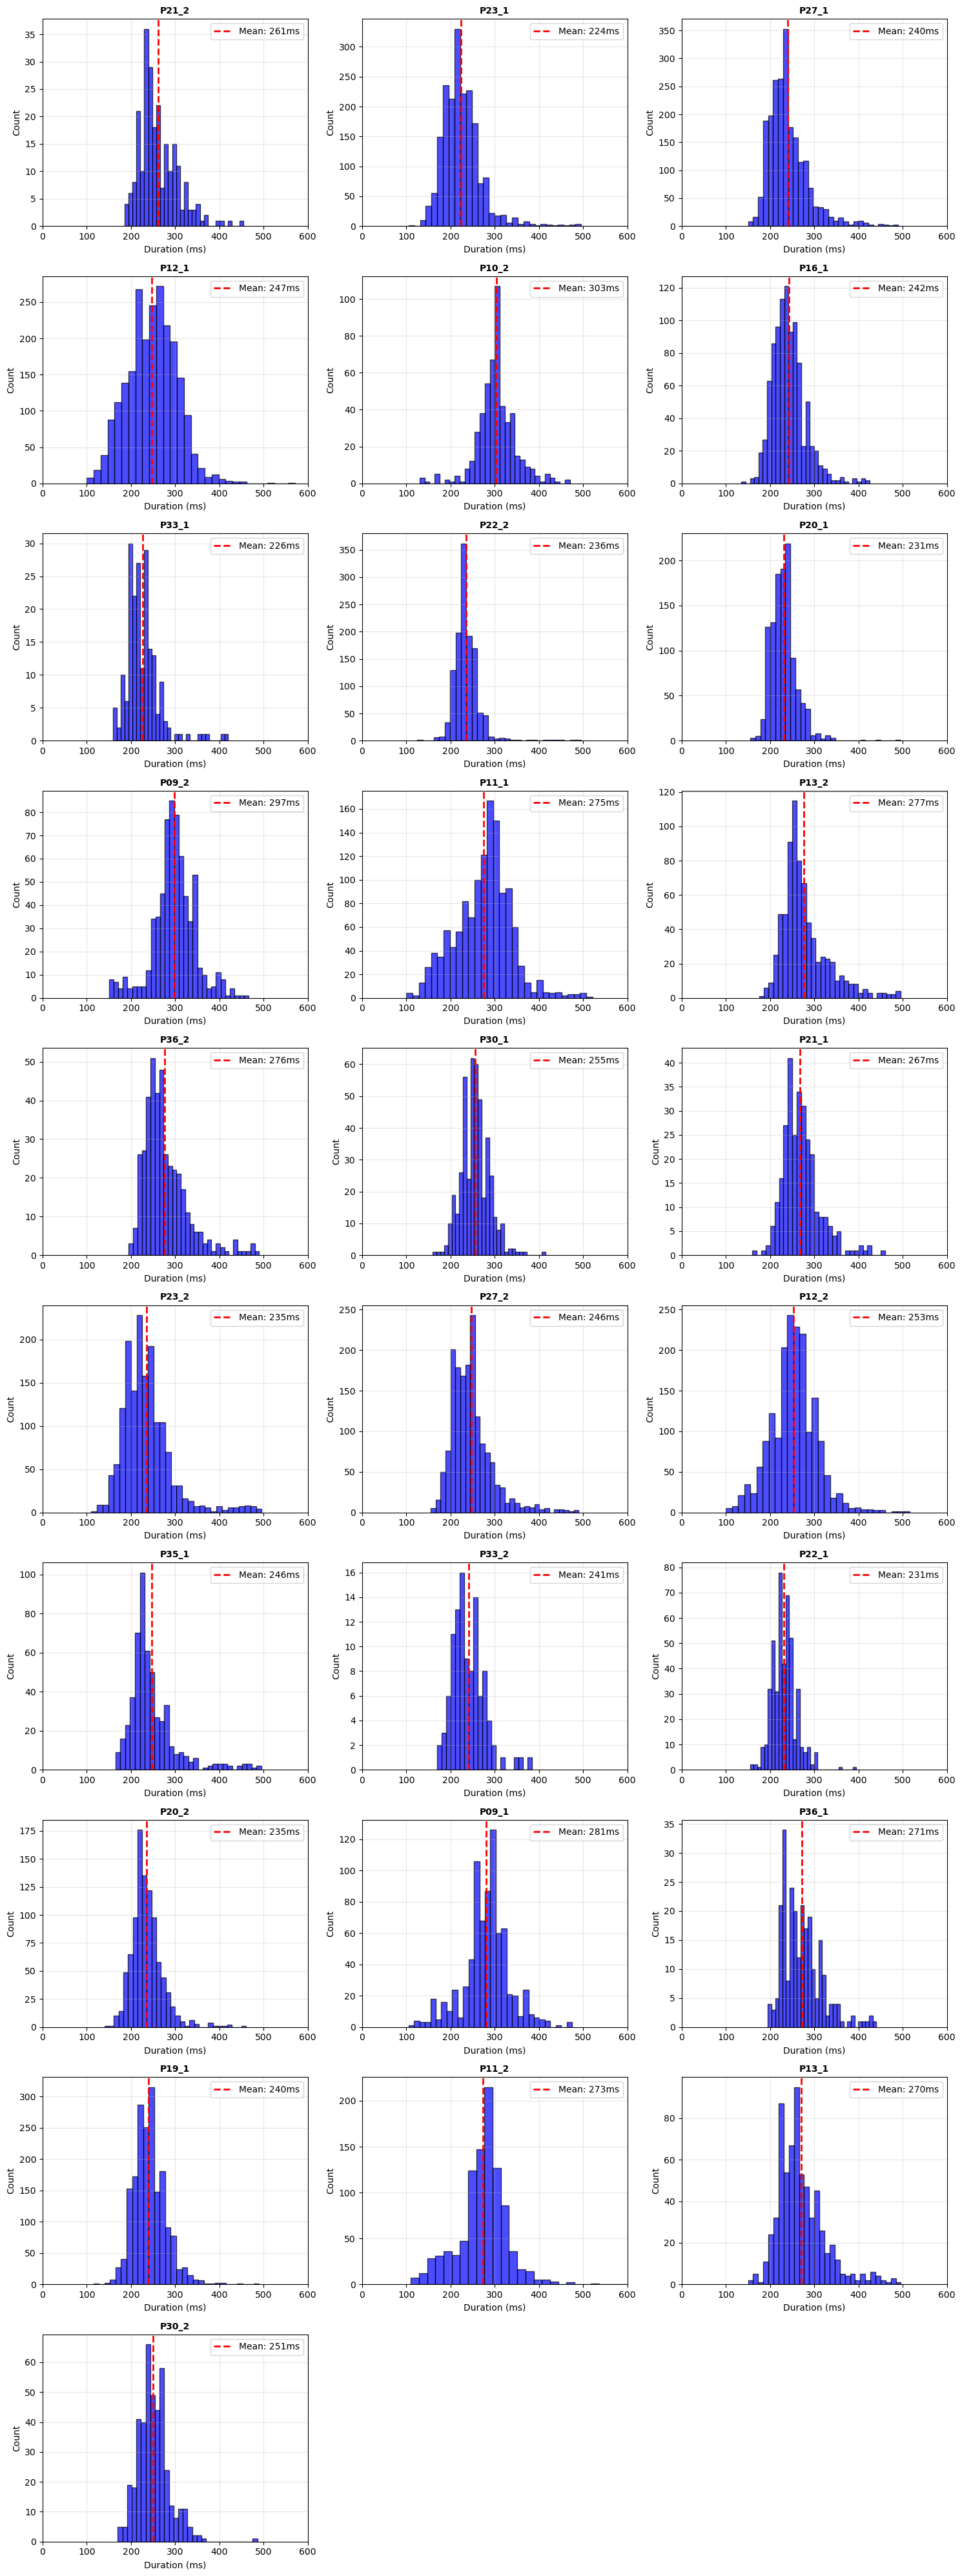

In [4]:
# BlINK DURATION DISTRIBUTIONS PER SESSION

# arranging figures
n_recordings = len(session_durations)
n_cols = 3
n_rows = ceil(n_recordings / n_cols)

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_recordings == 1:
    axes1 = [axes1]
elif n_rows == 1:
    axes1 = [axes1]
else:
    axes1 = axes1.flatten()

recording_names = list(session_durations.keys())

#plot
for i, (recording, durations) in enumerate(session_durations.items()):
    ax = axes1[i]
    if len(durations) > 0:
        mean_dur = np.mean(durations)
        ax.hist(durations, bins=min(30, len(durations)//5), 
                color='blue', alpha=0.7, edgecolor='black')
        ax.axvline(mean_dur, color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {mean_dur:.0f}ms')
        ax.set_title(f'{recording[:12]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Duration (ms)')
        ax.set_ylabel('Count')
        ax.set_xlim(0, 600)
        ax.grid(True, alpha=0.3)
        ax.legend()

for i in range(len(session_durations), len(axes1)):
    axes1[i].set_visible(False)

plt.tight_layout()
plt.show()

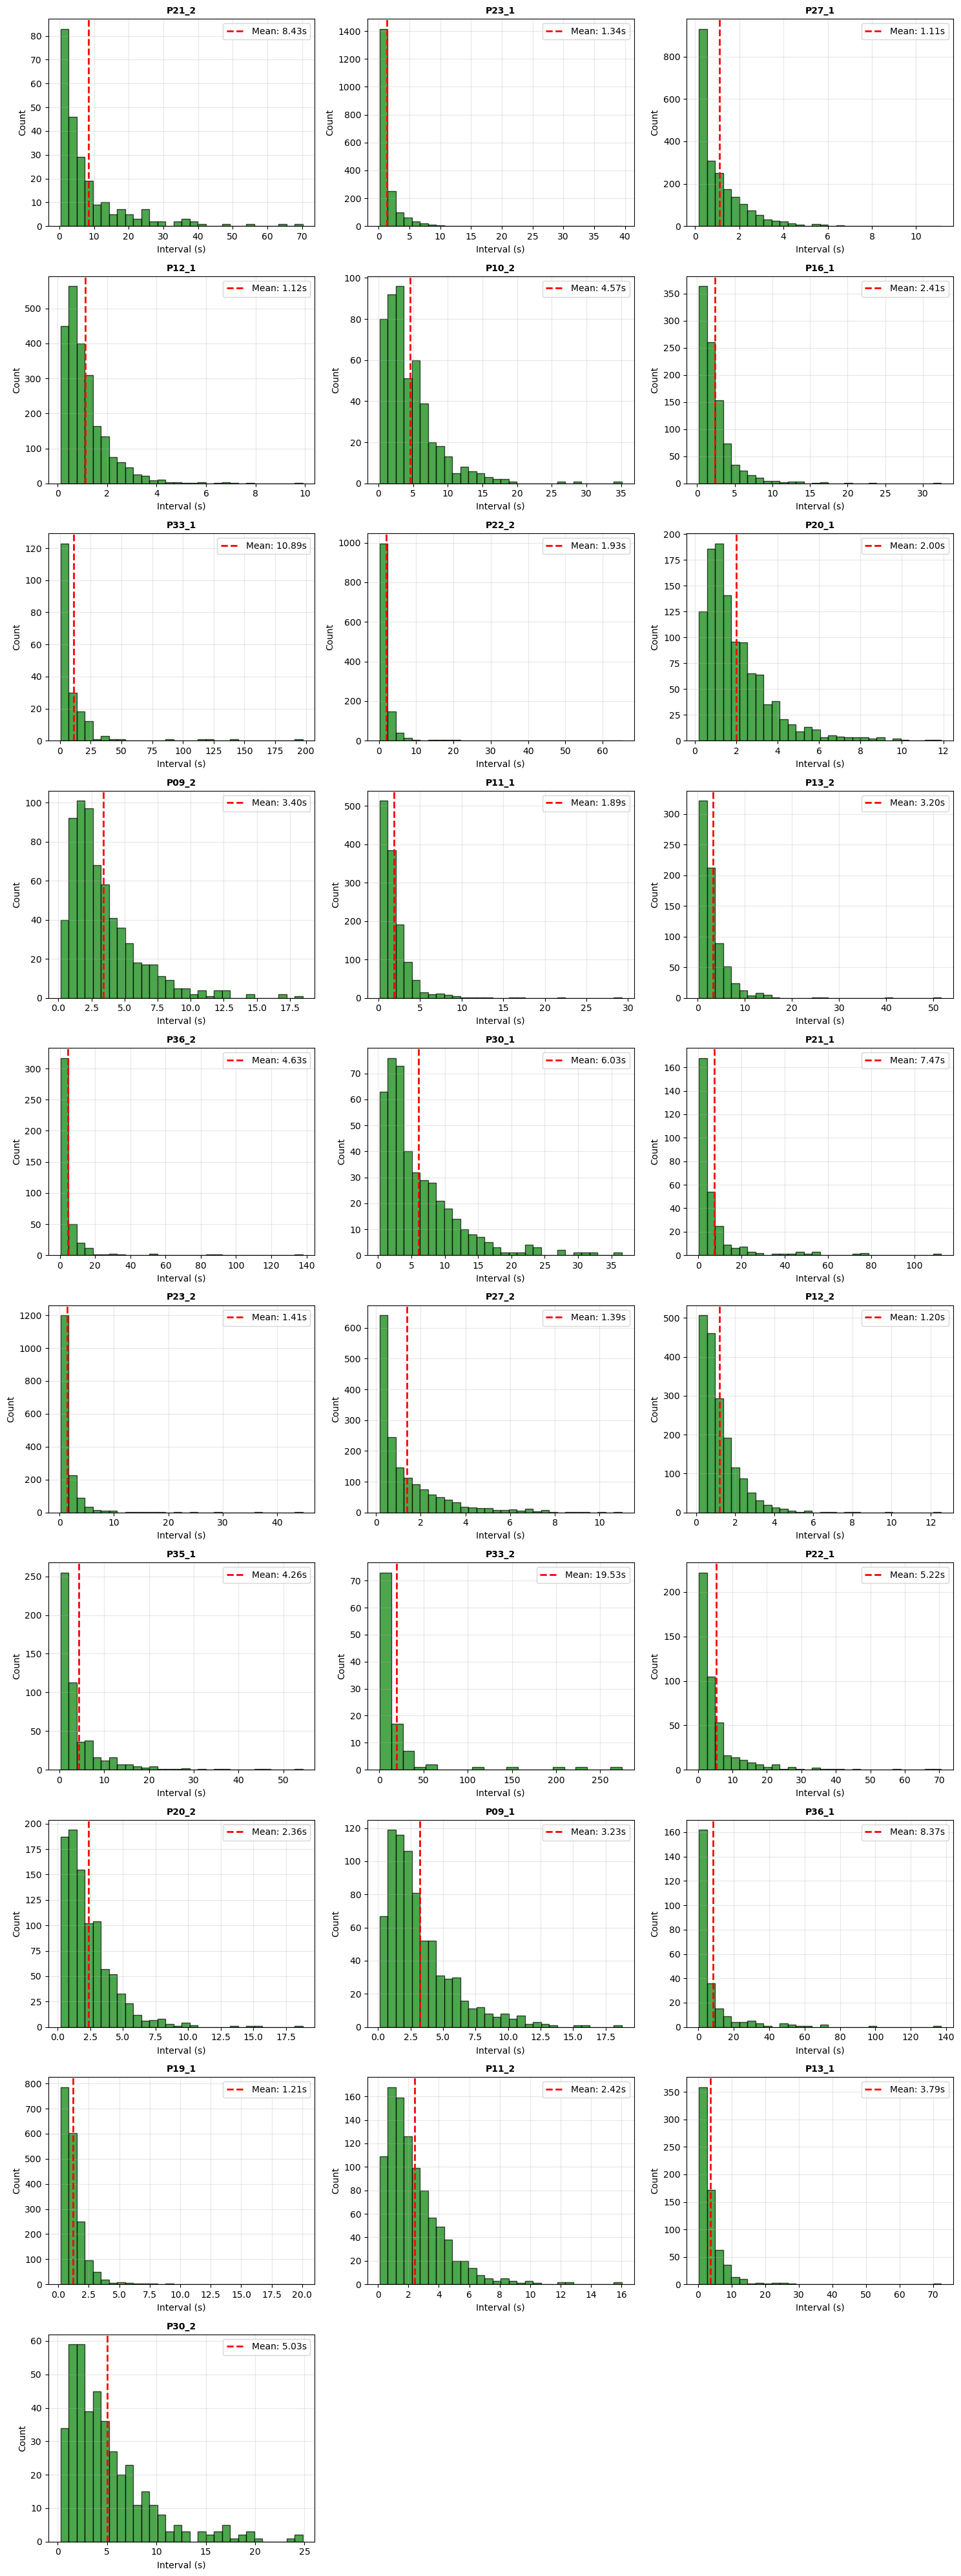

In [5]:
# INTERBLINK INTERVALS DISTRIBUTIONS PER SESSION

# Convert all interblink intervals to seconds
all_interblink_intervals_sec = np.array(all_interblink_intervals) / 1000 
session_interblink_intervals_sec = {rec: np.array(ints) / 1000 for rec, ints in session_interblink_intervals.items()}

# Histogram of interblink intervals per session
n_recordings = len(session_interblink_intervals_sec)
n_cols = 3
n_rows = ceil(n_recordings / n_cols)

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

# Ensure axes1 is always a flat numpy array for easy iteration
axes1 = np.array(axes1).flatten()

for i, (recording, intervals) in enumerate(session_interblink_intervals_sec.items()):
    ax = axes1[i]
    if len(intervals) > 0:
        mean_interval = np.mean(intervals)
        ax.hist(intervals, bins=min(30, max(1, len(intervals)//5)), 
                color='green', alpha=0.7, edgecolor='black')
        ax.axvline(mean_interval, color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {mean_interval:.2f}s')
        ax.set_title(f'{recording[:12]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Interval (s)')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)
        ax.legend()

# to hide unused subplots
for j in range(i + 1, len(axes1)):
    axes1[j].axis('off')

plt.tight_layout()

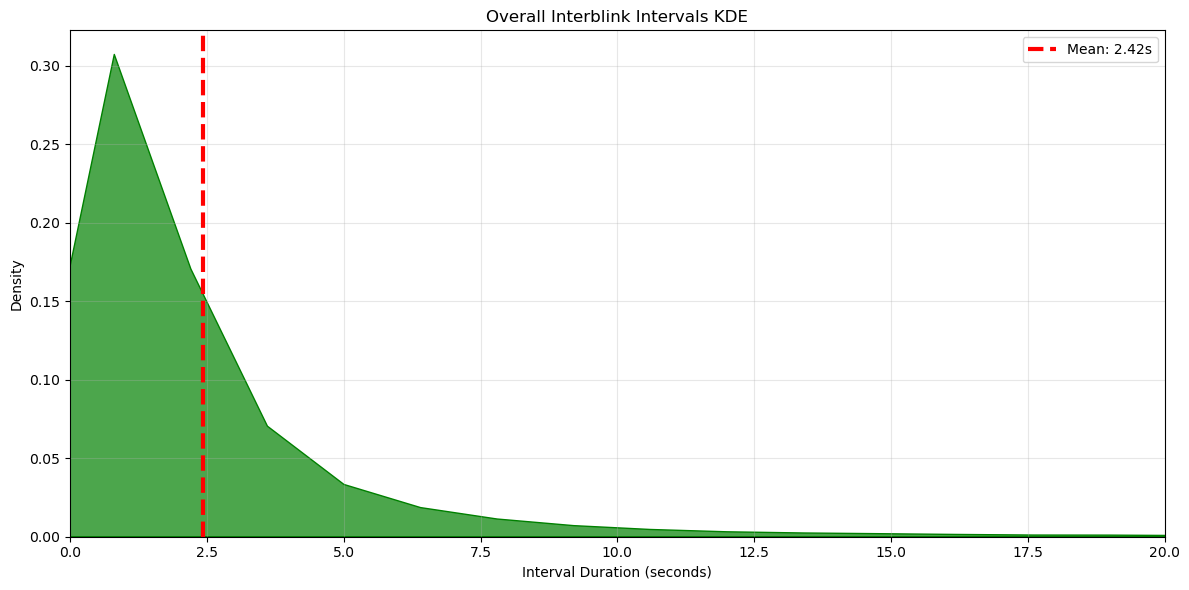

Total intervals: 26419
Mean: 2.42 ± 5.38 s
Range: 0.11 - 274.40 s


In [6]:
# OVERALL INTERBLINK INTERVALS DISTRIBUTION

fig2, ax_kde = plt.subplots(1, 1, figsize=(12, 6))
overall_mean = np.mean(all_interblink_intervals_sec)
sns.kdeplot(all_interblink_intervals_sec, ax=ax_kde, color='green', fill=True, alpha=0.7)
ax_kde.axvline(overall_mean, color='red', linestyle='--', linewidth=3,
              label=f'Mean: {overall_mean:.2f}s')
ax_kde.set_title('Overall Interblink Intervals KDE')
ax_kde.set_xlabel('Interval Duration (seconds)')
ax_kde.set_ylabel('Density')
ax_kde.set_xlim(0, 20)
ax_kde.grid(True, alpha=0.3)
ax_kde.legend()

plt.tight_layout()
plt.show()

print(f"Total intervals: {len(all_interblink_intervals_sec)}")
print(f"Mean: {np.mean(all_interblink_intervals_sec):.2f} ± {np.std(all_interblink_intervals_sec):.2f} s")
print(f"Range: {np.min(all_interblink_intervals_sec):.2f} - {np.max(all_interblink_intervals_sec):.2f} s")

In [7]:
summary_data = []
for recording_data in blink_rates_data:
    recording = recording_data['Recording']
    durations = session_durations[recording]
    
    # Store as numeric first
    stats = {
        'Recording': recording[:12],
        'N_Blinks': recording_data['N_Blinks'],
        'Mean_Dur_ms': np.mean(durations),        
        'Std_Dur_ms': np.std(durations),          
        'Blink_Rate': recording_data["Rate"],     
        'Min_ms': np.min(durations),              
        'Max_ms': np.max(durations)              
    }
    summary_data.append(stats)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df[['Recording', 'N_Blinks', 'Mean_Dur_ms', 'Std_Dur_ms', 
                        'Blink_Rate', 'Min_ms', 'Max_ms']]

n_blinks_list = [d['N_Blinks'] for d in blink_rates_data]

print(f"Total blinks: {len(all_durations):,}")
print(f"Mean duration: {np.mean(all_durations):.1f} ± {np.std(all_durations):.1f} ms")
print(f"Duration range: {np.min(all_durations):.0f} - {np.max(all_durations):.0f} ms")
print(f"Mean blink rate: {np.mean([d['Rate'] for d in blink_rates_data]):.1f} blinks/min")
print(f"Mean number of blinks: {np.mean(n_blinks_list):.1f}")
print(f"Std of number of blinks: {np.std(n_blinks_list):.1f}")
print(f"Blink count range: {np.min(n_blinks_list)} - {np.max(n_blinks_list)}")

#summary_df


Total blinks: 26,447
Mean duration: 250.0 ± 50.4 ms
Duration range: 100 - 666 ms
Mean blink rate: 24.4 blinks/min
Mean number of blinks: 944.5
Std of number of blinks: 632.7
Blink count range: 106 - 2294
